In [1]:
import json 
import os
import sys
import pandas as pd 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from dataset.paths import VQA_QUESTIONS, VQA_ANNOT, VQA_IMAGE_DIR, VQA_1K 

In [2]:
sem = "/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl"
sem_data = []
with open(sem, 'r') as f:
    for line in f:
        sem_data.append(json.loads(line)) 
sdf = pd.DataFrame(sem_data)

In [ ]:
from dataset.vqav2 import VQADataset
from extract_vqa import get_vqa_questions  

questions = get_vqa_questions() 
qids = [d['question_id'] for d in questions]  
 
dataset = VQADataset( image_dir_path="/home/david/Desktop/yuna/data/val2014", 
                        question_path=VQA_QUESTIONS, 
                        annotations_path=VQA_ANNOT, 
                        prompt='', format=False)  
                        
examples = [q for q in dataset if q['question_type'] == 'none of the above']
for i, example in enumerate(examples[:5]):  # show first 5 examples
    print(f"{example}")

{'image_id': 262148, 'question': 'Where is he looking?', 'question_id': 262148000, 'question_type': 'none of the above', 'multiple_choice_answer': 'down', 'answers': [{'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 1}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 2}, {'answer': 'at table', 'answer_confidence': 'yes', 'answer_id': 3}, {'answer': 'skateboard', 'answer_confidence': 'yes', 'answer_id': 4}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 5}, {'answer': 'table', 'answer_confidence': 'yes', 'answer_id': 6}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 7}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 8}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 9}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 10}], 'answer_type': 'other', 'image': '/home/david/Desktop/yuna/data/val2014/COCO_val2014_000000262148.jpg'}
{'image_id': 131089, 'question': 'Did the batter hit the ball?', 'question_i

## Clustering 

In [ ]:
unique_counts = sdf.apply(lambda x: x.map(tuple) if isinstance(x.iloc[0], list) else x).nunique()
print(unique_counts)

image_id        980
question        969
question_id    1000
w                11
op               12
p               102
sub             601
obj             344
ent               9
attr             10
ans              12
space             4
sp               13
rel              16
dx                8
neg               1
know              2
txt               2
q                 2
dtype: int64


In [33]:
sdf.head()

,image_id,question,question_id,w,op,p,sub,obj,ent,attr,ans,space,sp,rel,dx,neg,know,txt,q
0,524577,What number of clocks are on this tower?,524577006,how_many,count,None,clocks,tower,object,None,num,num,[],[],[],False,False,False,good
1,524577,Where is the clock located?,524577024,where,spat,None,clock,None,object,loc,loc,cat,[],[],[],False,False,False,good
2,524577,What type of numbers are on the clock?,524577027,what,attr,type,numbers,clock,object,type,cat,cat,[],[],[],False,False,False,good
3,524799,How old is the child?,524799000,how_old,temp,None,child,None,person,age,age,num,[],[],[],False,False,False,good
4,524850,How many engines do you see?,524850001,how_many,count,None,engines,None,object,None,num,num,[],[],[],False,False,False,good


In [21]:
sdf.groupby(['w'])['question'].count()

w
how           2
how_long      3
how_many     98
how_old       1
other         3
what        428
where        33
which        13
who           7
why          12
yesno       400
Name: question, dtype: int64

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L12-v2")  # small + good 
X = model.encode(qs, normalize_embeddings=True)

In [ ]:

def wrap_every_n_words(text, n=3):
    words = text.split()
    lines = [" ".join(words[i:i+n]) for i in range(0, len(words), n)]
    return "\n".join(lines) 

969 969
11 ['how', 'how_long', 'how_many', 'how_old', 'other', 'what', 'where', 'which', 'who', 'why', 'yesno']


<Figure size 640x480 with 0 Axes>

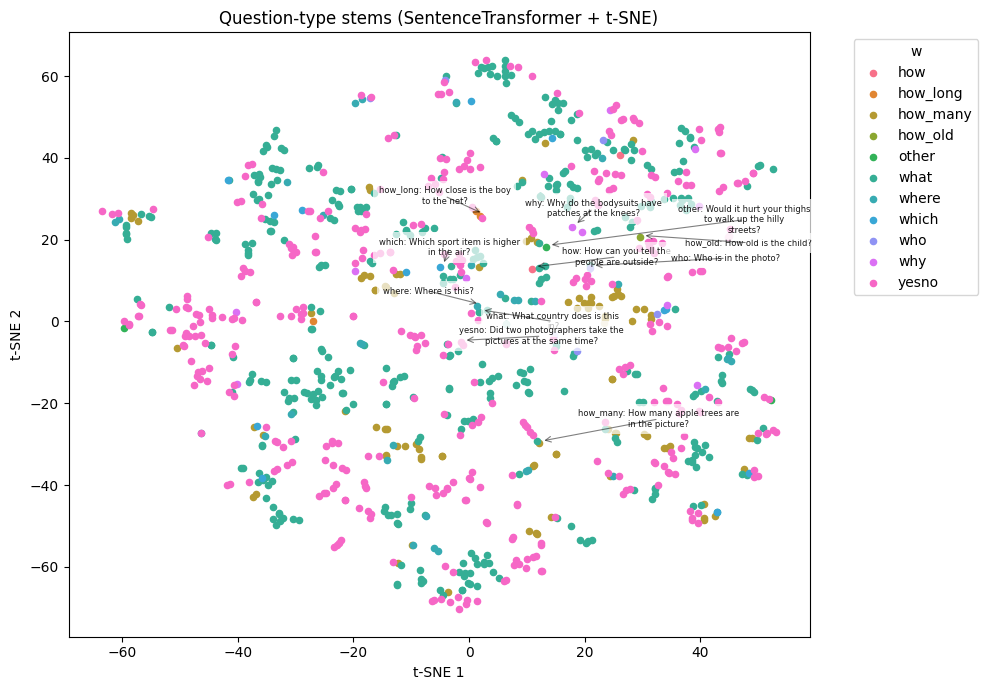

969 969
12 ['act', 'attr', 'cause', 'comp', 'count', 'exist', 'ident', 'know', 'other', 'spat', 'temp', 'text']


<Figure size 640x480 with 0 Axes>

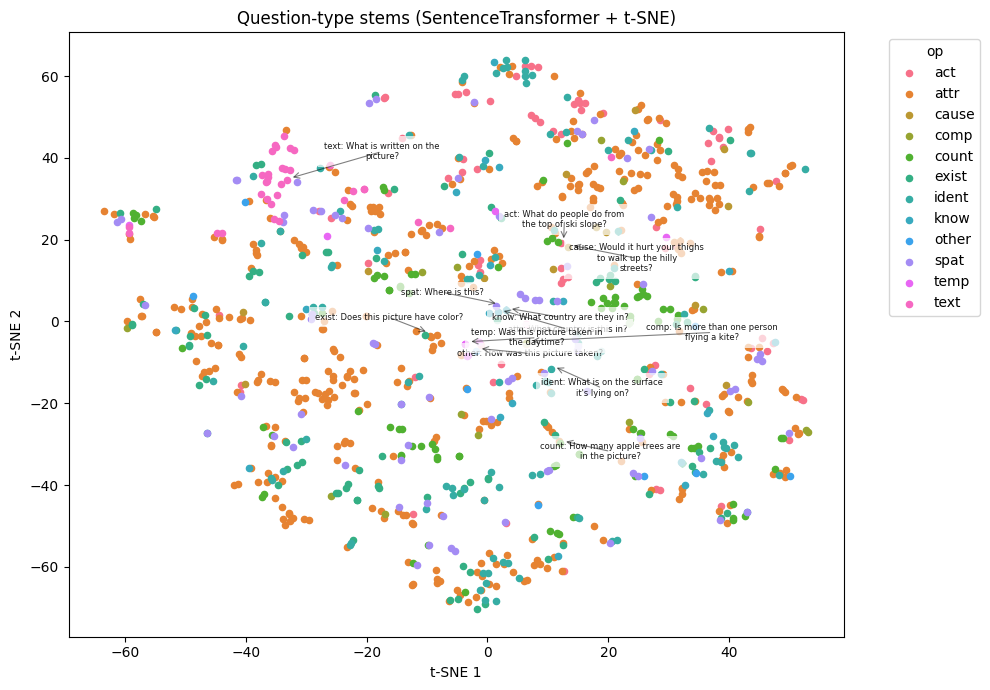

969 969
9 ['animal', 'food', 'object', 'other', 'person', 'place', 'product', 'text', 'vehicle']


<Figure size 640x480 with 0 Axes>

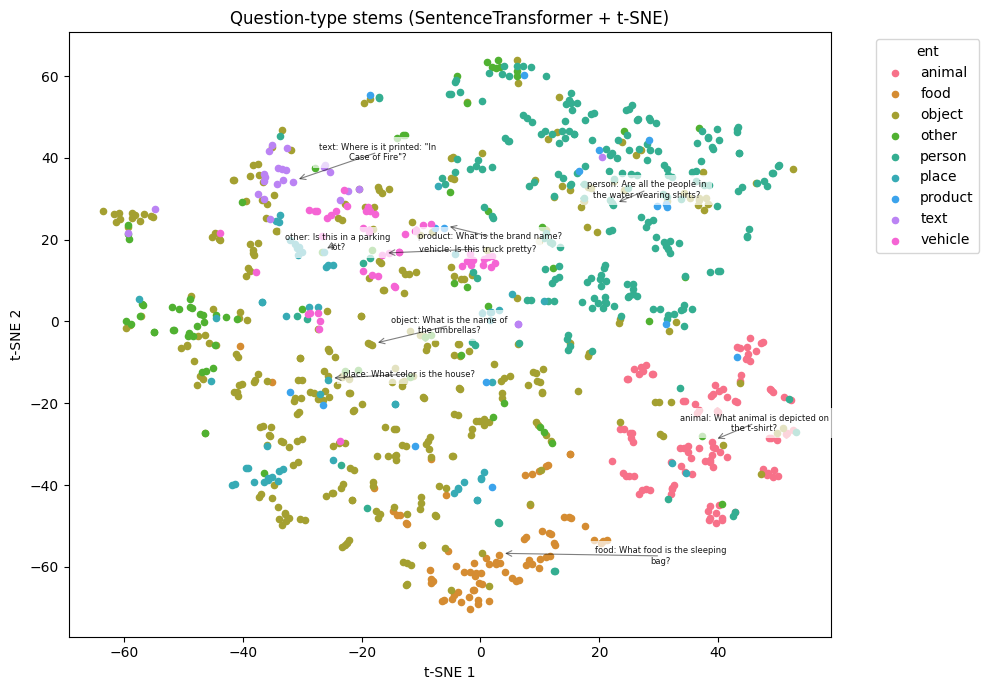

969 969
11 ['None', 'age', 'color', 'count', 'dur', 'ident', 'loc', 'mat', 'name', 'other', 'type']


<Figure size 640x480 with 0 Axes>

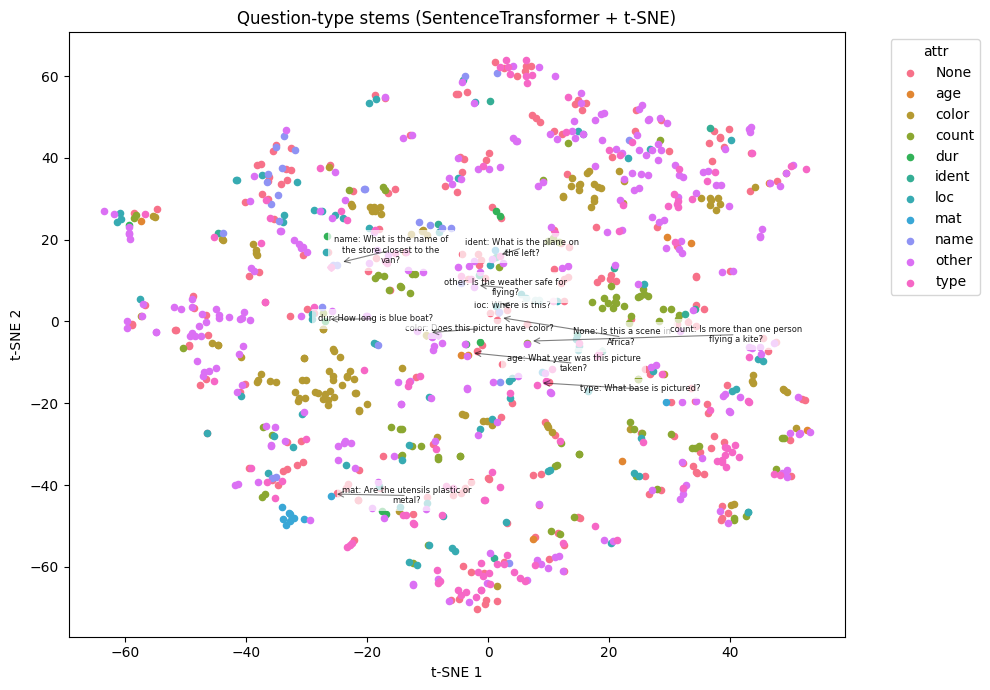

969 969
12 ['age', 'bool', 'cat', 'color', 'dur', 'loc', 'mat', 'num', 'object', 'open', 'person', 'text']


<Figure size 640x480 with 0 Axes>

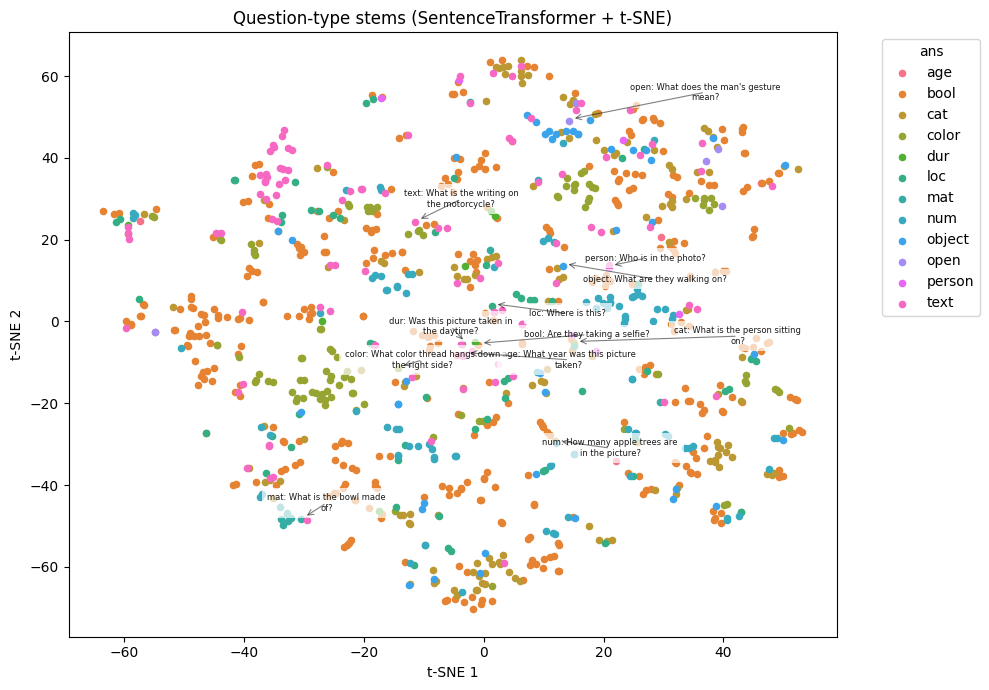

969 969
4 ['bin', 'cat', 'num', 'open']


<Figure size 640x480 with 0 Axes>

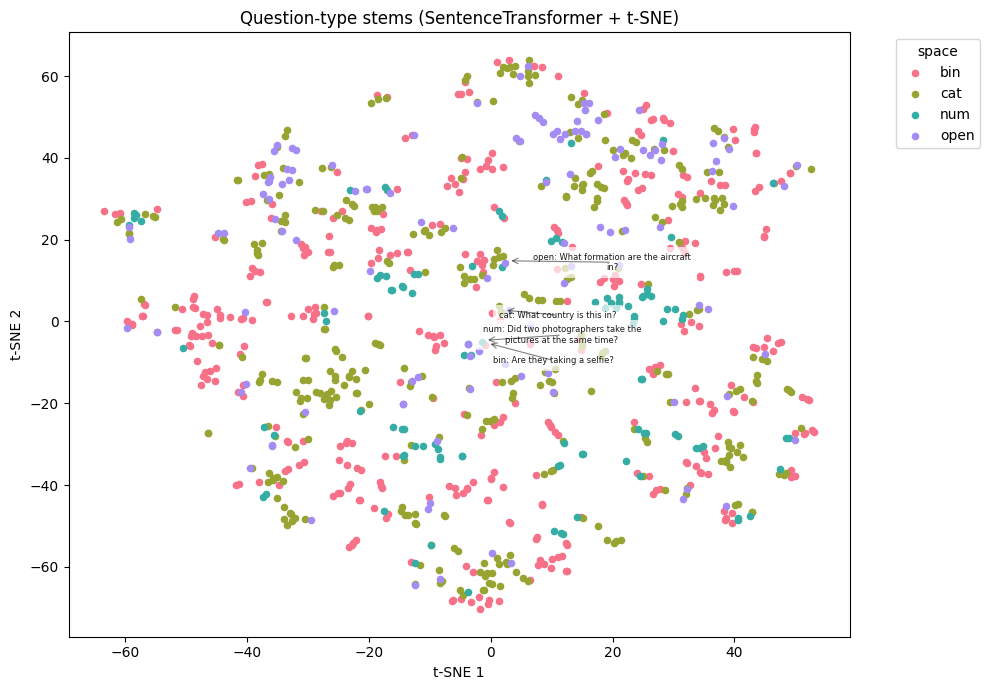

In [42]:
import seaborn as sns
from sklearn.manifold import TSNE 
import matplotlib.pyplot as plt 
from adjustText import adjust_text
import numpy as np 

def get_labels(qtype): 
    q_to_w = (
        sdf[["question", qtype]]
        .drop_duplicates()
        .set_index("question")[qtype] 
        .to_dict()
    )

    labels = [q_to_w[q] for q in qs] 
    print(len(qs), len(labels) )
    return labels  

def visualize_by_semantics(qtype, labels, unique_labels): 
    # colors = sns.color_palette("Set2", len(unique_labels)) 
    colors = sns.color_palette("husl", len(unique_labels))   
    
    Z = TSNE(
        n_components=2,
        perplexity=min(10, max(2, len(qs)//6)),
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(X)

    plt.clf() 
    plt.figure(figsize=(10, 7))
    for lab, color in zip(unique_labels, colors): 
        idx = [i for i, l in enumerate(labels) if l == lab]
        plt.scatter(
            Z[idx, 0],
            Z[idx, 1],
            label=lab,
            color=color, 
            s=20
        )
 
    texts = []
    for lab in unique_labels:
        idx = [i for i, l in enumerate(labels) if l == lab]
        center = Z[idx].mean(axis=0)
        d = np.linalg.norm(Z[idx] - center, axis=1)
        best_i = idx[np.argmin(d)]

        # create text with initial offset
        t = plt.text(
            Z[best_i, 0] + 0.5,  # initial x offset
            Z[best_i, 1] + 0.5,  # initial y offset
            f"{lab}: {wrap_every_n_words(qs[best_i], n=5)}",
            fontsize=6,
            alpha=0.9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )
        texts.append(t)

    # automatically reduce overlaps + draw arrows to points
    adjust_text(
        texts,
        x=Z[:, 0], y=Z[:, 1],
        arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.5),
        expand_text=(1.05, 1.2),
        expand_points=(1.2, 1.4),
        force_text=(0.2, 0.3),
        force_points=(0.1, 0.2)
    )

    plt.legend(title=qtype, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title("Question-type stems (SentenceTransformer + t-SNE)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show() 
    
qs = sorted(sdf["question"].unique())
for qtype in ['w', 'op', 'ent', 'attr', 'ans', 'space']  : 

    labels = get_labels(qtype) 
    labels = [str(label) if label is None else label for label in labels] # clean label (nonetype)
    unique_labels = sorted(set(labels)) 
    print(len(unique_labels), unique_labels)
    visualize_by_semantics(qtype, labels, unique_labels)   

In [ ]:
import umap 

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
Z = reducer.fit_transform(X)

cats = pd.Categorical(labels)
plt.figure(figsize=(10, 7))
plt.scatter(Z[:, 0], Z[:, 1], c=cats.codes, s=80)

for i, qt in enumerate(qtypes):
    plt.text(Z[i, 0], Z[i, 1], qt, fontsize=8, alpha=0.8)

plt.title("Question-type stems (SentenceTransformer + UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering 

# 2) Cluster (simple + stable)
# Choose k based on how many groups you want (try 6~12)
k = 8
clusterer = AgglomerativeClustering(
    n_clusters=k,
    metric="cosine",
    linkage="average"
)
labels = clusterer.fit_predict(X)

# 3) Put into a table and list groups
df_clusters = pd.DataFrame({"question_type": qs, "cluster": labels}).sort_values(["cluster","question_type"])

for c, g in df_clusters.groupby("cluster"):
    print(f"\n=== Cluster {c} (n={len(g)}) ===")
    print(g["question_type"].to_list())

## Question type 

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

def show_qtype_proportion(dataset): 
    df = pd.DataFrame(list(dataset), columns=['answer_type', 'question_type', 'question_id']) 
    question_counts = df['question_type'].value_counts() 

    plt.figure(figsize=(10,20))
    question_counts_norm = question_counts / question_counts.sum()
    question_counts_norm.plot(kind='barh')
    plt.xlabel('Proportion')
    plt.title(f'Proportion of Question Types in VQA Validation Set (# {len(dataset)})') 
    plt.tight_layout()
    plt.show()
    return df 

filtered_indices = [i for i, q in enumerate(dataset.questions) if q['question_id'] in qids]
filtered_dataset = [dataset[i] for i in filtered_indices]

original_dataset = show_qtype_proportion(dataset)
df = show_qtype_proportion(filtered_dataset) 
filtered_dataset[0], len(filtered_dataset) 

NameError: name 'dataset' is not defined

In [ ]:

grouped = df.groupby(['answer_type', 'question_type']).agg(question_id_count=('question_id', 'count')).reset_index()

    answer_type question_type  question_id_count
0        number       are the                  2
1        number     are there                  3
2        number     are these                  2
3        number       can you                  2
4        number      does the                  8
..          ...           ...                ...
138      yes/no  what are the                  2
139      yes/no       what is                  2
140      yes/no   what is the                  4
141      yes/no           why                  3
142      yes/no    why is the                  1

[143 rows x 3 columns]


In [41]:
from datasets import load_dataset

textvqa = load_dataset("lmms-lab/textvqa", split="validation")  
okvqa = load_dataset("lmms-lab/OK-VQA", split="val2014") 

Generating val2014 split: 100%|██████████| 5046/5046 [00:01<00:00, 3682.05 examples/s]
